In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_divisible_rates(data, power):
    """
    데이터에서 특정 스케일(scale)로 나누어 떨어지는 값들을 추출합니다.

    :param data: (a, b, c) 형태의 튜플로 구성된 튜플 e.g. non_consecutive_cycles_t_n1_4[(0, 6, 21, 1)]
    :return: 특정 스케일로 나누어 떨어지는 a 값들의 리스트
    """
    data = list(data)
    divisible_values = []
    for item in data:
        a_value = item[0]  # 튜플의 첫 번째 값 추출
        if len(str(a_value)) <= -power + 2: 
            divisible_values.append(a_value)
    return divisible_values

def interval_of_cycle_rates(data, power, chaotic_only : bool):
    """
    데이터에서 특정 스케일(scale)로 나누어 떨어지는 값들 간의 간격을 분석합니다.

    :param divisible_values: 특정 스케일로 나누어 떨어지는 a 값들의 리스트
    :param scale: 나눌 값 (스케일)
    :return: 간격을 스케일로 나눈 값들의 리스트
    """

    divisible_values = get_divisible_rates(data, power)

    scale = 10**power

    interval_ratios = []

    if chaotic_only :
        divisible_values_ = []
        for i in range(1, len(divisible_values)):
            interval = divisible_values[i] - divisible_values[i-1]
            ratio = round(interval / scale)
            if ratio != 1 :
                interval_ratios.append(ratio)
                divisible_values_.append(divisible_values[i-1])
        divisible_values_.append(divisible_values[i])
        divisible_values = divisible_values_

    else :
        for i in range(1, len(divisible_values)):
            interval = divisible_values[i] - divisible_values[i-1]
            ratio = round(interval / scale)
            interval_ratios.append(ratio)

    return divisible_values, interval_ratios

def get_chaotic_profile(non_consecutive_cycles, power, chaotic_only):

    powers = list(range(power, -1, 1)) # power = -4일땐 [-2, -3, -4]
    choatic_profile = dict()
    for power in powers :

        chaos_interval = dict()
        cycle_idx = 0
        for cycle in non_consecutive_cycles.keys():

            data = non_consecutive_cycles[cycle]
            divisible_values, interval_ratios = interval_of_cycle_rates(data, power, chaotic_only = chaotic_only)
            chaos_interval[cycle_idx] = (cycle, divisible_values, interval_ratios)
            
            # print(f"{10**power}로 나누어 떨어지는 값: {divisible_values}")
            # print(f"{10**power} 스케일에서 간격 비율: {interval_ratios}")

            cycle_idx += 1

        choatic_profile[power] = chaos_interval

    return choatic_profile

def plot_chaotic_interval(inter_lag : int, choas_profiles : dict, chaotic_only : bool) : 

    """
    Args
    choas_profiles : get_chaotic_profile의 리턴값 혹은 gather_chaotic_for_interlag의 두번째 리턴값을
                     value로 하고 inter_lag를 key로 하는 딕셔너리

    """

    choas_profile = choas_profiles[inter_lag]

    powers = []
    for power in choas_profile.keys():
        powers.append(power)
    powers.sort(reverse=True)


    if chaotic_only :
        print(f"at inter_lag {inter_lag} :")
        for power in powers :
            print(f"at rate {10**power}:")
            for cycle_idx in range(len(choas_profile[power])) :
                
                # interval_ratios = choas_profile[power][cycle_idx][2]
                interval_ratios = choas_profile[power][cycle_idx][2]  # y축 데이터
                x_values = choas_profile[power][cycle_idx][1][:-1]       # x축 데이터

                if interval_ratios != list():

                    if len(interval_ratios) <= 10 :
                        plt.figure(figsize=(20, 2))
                    else :
                        plt.figure(figsize=(30, 3))

                    # x축, y축 데이터를 사용하여 plot
                    plt.plot(x_values, interval_ratios, marker='o', linestyle='-', color='blue')
                    plt.title(f'Interval Ratios of {choas_profile[power][cycle_idx][0]} at rate {10**power}')
                    plt.xlabel('Rate')  # x축 레이블 변경 (예: Rate)
                    plt.ylabel('Interval Ratio')
                    plt.grid(True)
                    plt.show()

            print("\n\n")

    else :
        print(f"at inter_lag {inter_lag} :")
        for power in powers :
            print(f"at rate {10**power}:")
            for cycle_idx in range(len(choas_profile[power])) :
                
                # interval_ratios = choas_profile[power][cycle_idx][2]
                interval_ratios = choas_profile[power][cycle_idx][2]  # y축 데이터
                x_values = choas_profile[power][cycle_idx][1][:-1]       # x축 데이터

                if interval_ratios != list():

                    if len(interval_ratios) <= 10 :
                        plt.figure(figsize=(20, 2))
                    else :
                        plt.figure(figsize=(30, 3))

                    # x축, y축 데이터를 사용하여 plot
                    plt.plot(x_values, interval_ratios, marker='o', linestyle='-', color='blue')

                    plt.title(f'Interval Ratios of {choas_profile[power][cycle_idx][0]} at rate {10**power}')
                    plt.xlabel('Rate')  # x축 레이블 변경 (예: Rate)
                    plt.ylabel('Interval Ratio')
                    plt.grid(True)
                    plt.show()

            print("\n\n")

def plot_chaotic_interval_closely(choas_profiles : dict, inter_lag : int, power : int, cycle_idx : int, size : int, 
                                  chaotic_only : bool) :

    cycle_to_see = choas_profiles[inter_lag][power][cycle_idx]
    intervals = cycle_to_see[2]
    iteration = int(np.ceil(len(intervals) / size))

    if not chaotic_only :
        x_values = cycle_to_see[1][:-1]
        for page in range(iteration) :

            # x축 범위를 데이터 범위에 맞게 설정
            start_idx = page * size
            end_idx = (page + 1) * size
            x_values_ = x_values[start_idx:end_idx]
            # x_values = range(len(intervals[start_idx:end_idx]))

            # 1. 선 그래프
            plt.figure(figsize=(30, 3))
            plt.plot(x_values_, intervals[start_idx:end_idx], marker='o', linestyle='-', color='blue')
            plt.title(f'Chaotic intervals of {cycle_to_see[0]} at lag {inter_lag}, power {power}')
            plt.xlabel('x-axis')
            plt.ylabel(f'Interval at ')
            plt.grid(True)
            plt.xlim(min(x_values_), max(x_values_))
            plt.show()

    else :
        for page in range(iteration) :

            # x축 범위를 데이터 범위에 맞게 설정
            start_idx = page * size
            end_idx = (page + 1) * size
            x_values = [i + start_idx for i in range(len(intervals[start_idx:end_idx]))] 
            # x_values = [i + start_idx for i in range(len(intervals[start_idx:end_idx]))]  # 변경된 부분

            # 1. 선 그래프
            plt.figure(figsize=(30, 3))
            plt.plot(x_values, intervals[start_idx:end_idx], marker='o', linestyle='-', color='blue')
            plt.title(f'Chaotic intervals of {cycle_to_see[0]} at lag {inter_lag}, power {power}')
            plt.xlabel('x-axis')
            plt.ylabel(f'Interval at ')
            plt.grid(True)
            plt.xlim(min(x_values), max(x_values))
            plt.show()


    return intervals


In [ ]:
from util import cycle_rBD_from_pkl

power = -5
rate_start = 0.0
rate_end = 1.5
lag = 1

choatic_profiles = dict()

pkl_file = f'cycle_rBD_t_notes{lag}_1e{power}_{rate_start}~{rate_end}_n.pkl'
non_consecutive_cycles_m = cycle_rBD_from_pkl(pkl_file, dir=f"./pickle/fp_error/lag {lag}")

chaotic_only = True
choatic_profile = get_chaotic_profile(non_consecutive_cycles_m, power = power, chaotic_only=chaotic_only)
choatic_profiles[lag] = choatic_profile

plot_chaotic_interval(lag, choatic_profiles, chaotic_only=chaotic_only)

In [17]:
power = -3
for cycle_idx in choatic_profile[power].keys():
    print(choatic_profile[power][cycle_idx][:3])

((0, 6, 21, 1), [3e-05, 4e-05, 0.002, 0.005, 0.016, 0.019, 0.022, 0.025, 0.028, 0.031, 0.034, 0.037, 0.048, 0.051, 0.054, 0.057, 0.06, 0.063, 0.066, 0.069, 0.08, 0.083, 0.086, 0.089, 0.092, 0.095, 0.098, 0.101, 0.112, 0.115, 0.118, 0.121, 0.124, 0.127, 0.13, 0.141, 0.144, 0.147, 0.15, 0.153, 0.156, 0.159, 0.162, 0.173, 0.176, 0.179, 0.182, 0.185, 0.188, 0.191, 0.194, 0.205, 0.208, 0.211, 0.214, 0.217, 0.22, 0.223, 0.226, 0.237, 0.24, 0.243, 0.246, 0.249, 0.252, 0.255, 0.266, 0.269, 0.272, 0.275, 0.278, 0.281, 0.284, 0.287, 0.298, 0.301, 0.304, 0.307, 0.31, 0.313, 0.316, 0.319, 0.33, 0.333, 0.336, 0.339, 0.342, 0.345, 0.348, 0.362, 0.365, 0.368, 0.371, 0.374, 0.377, 0.38, 0.391, 0.394, 0.397, 0.4, 0.403, 0.406, 0.409, 0.412, 0.423, 0.426, 0.429, 0.432, 0.435, 0.438, 0.441, 0.444, 0.455, 0.458, 0.461, 0.464, 0.467, 0.47, 0.473, 0.487, 0.49, 0.493, 0.496, 0.499, 0.502, 0.505, 0.516, 0.519, 0.522, 0.525, 0.528, 0.531, 0.534, 0.537, 0.54, 0.551, 0.554, 0.557, 0.56, 0.563, 0.566, 0.569, 0.57

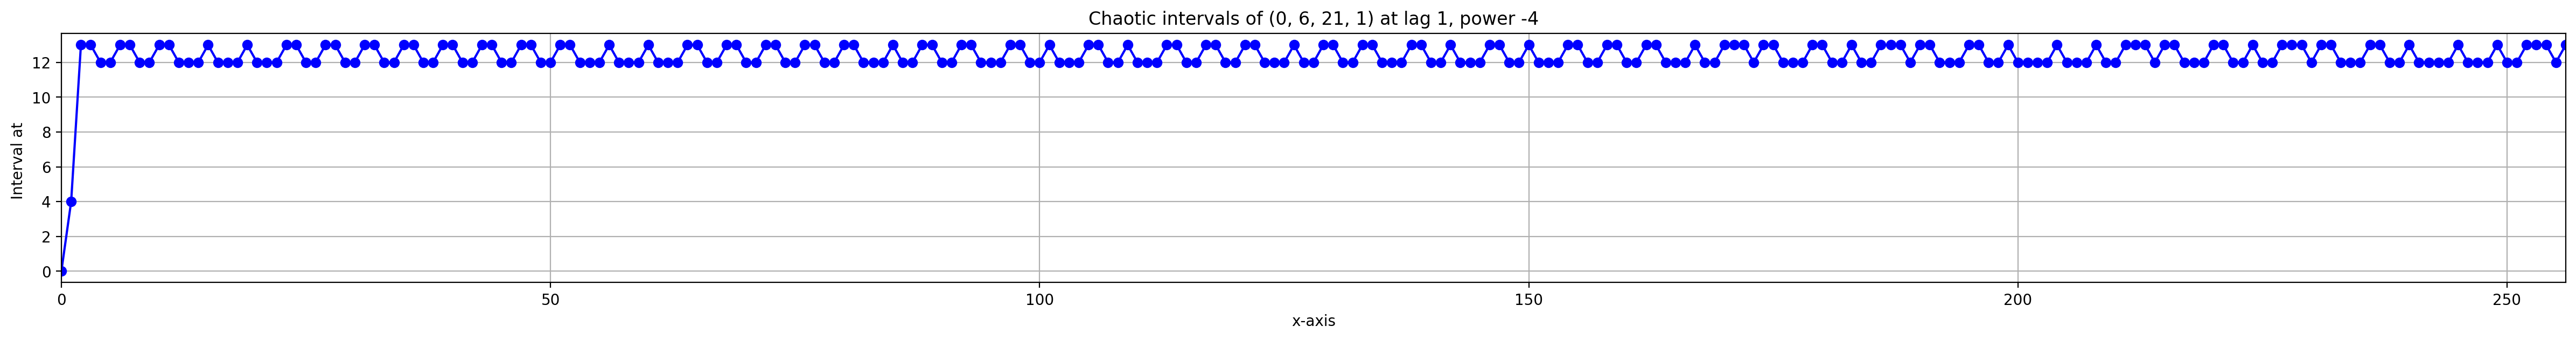

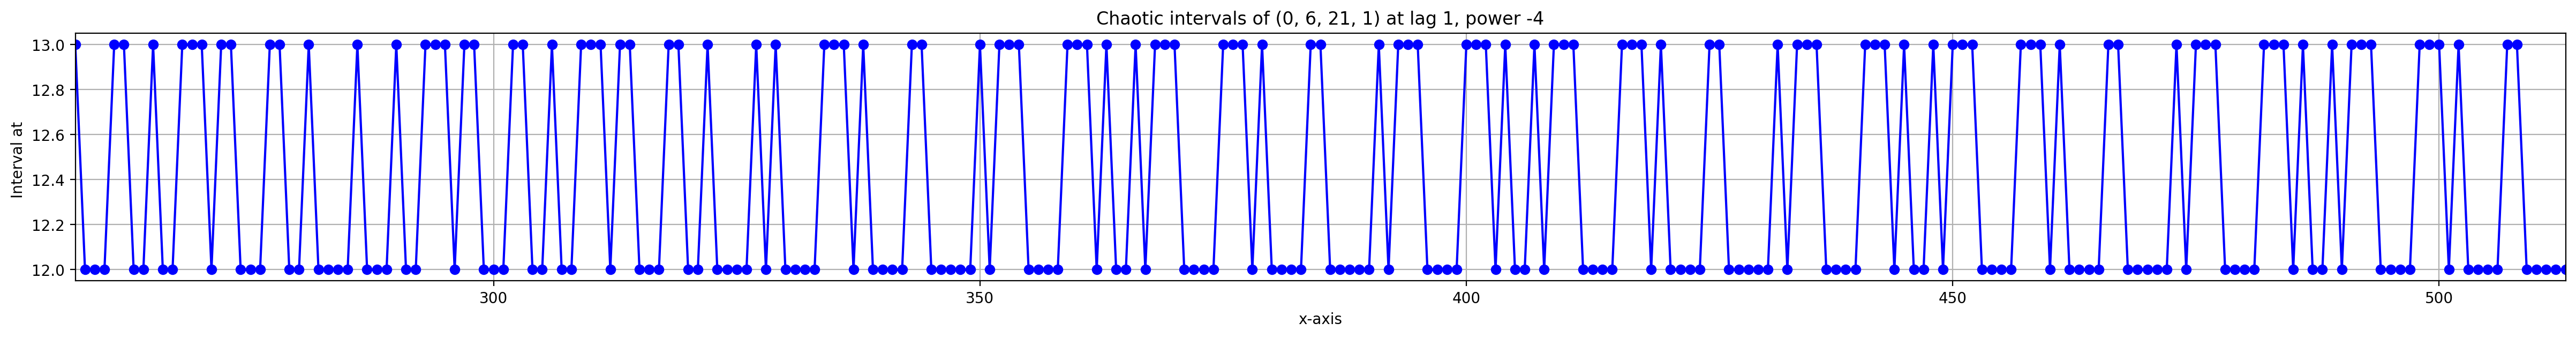

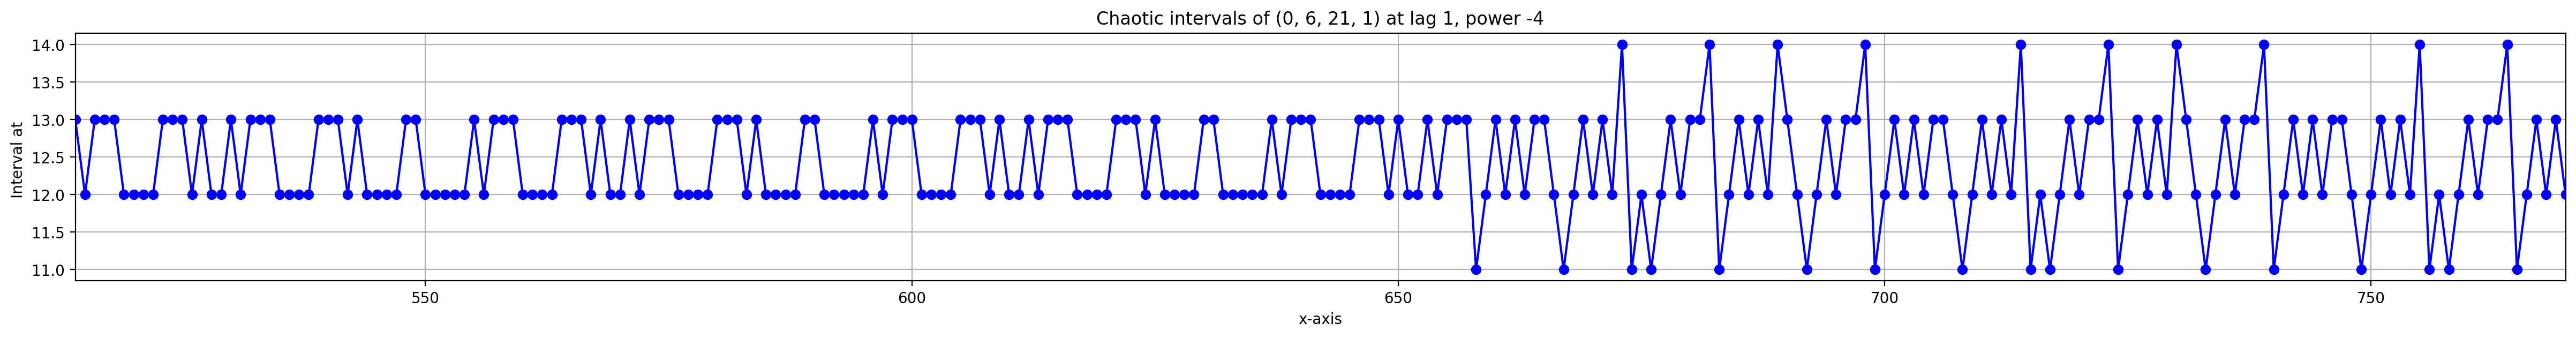

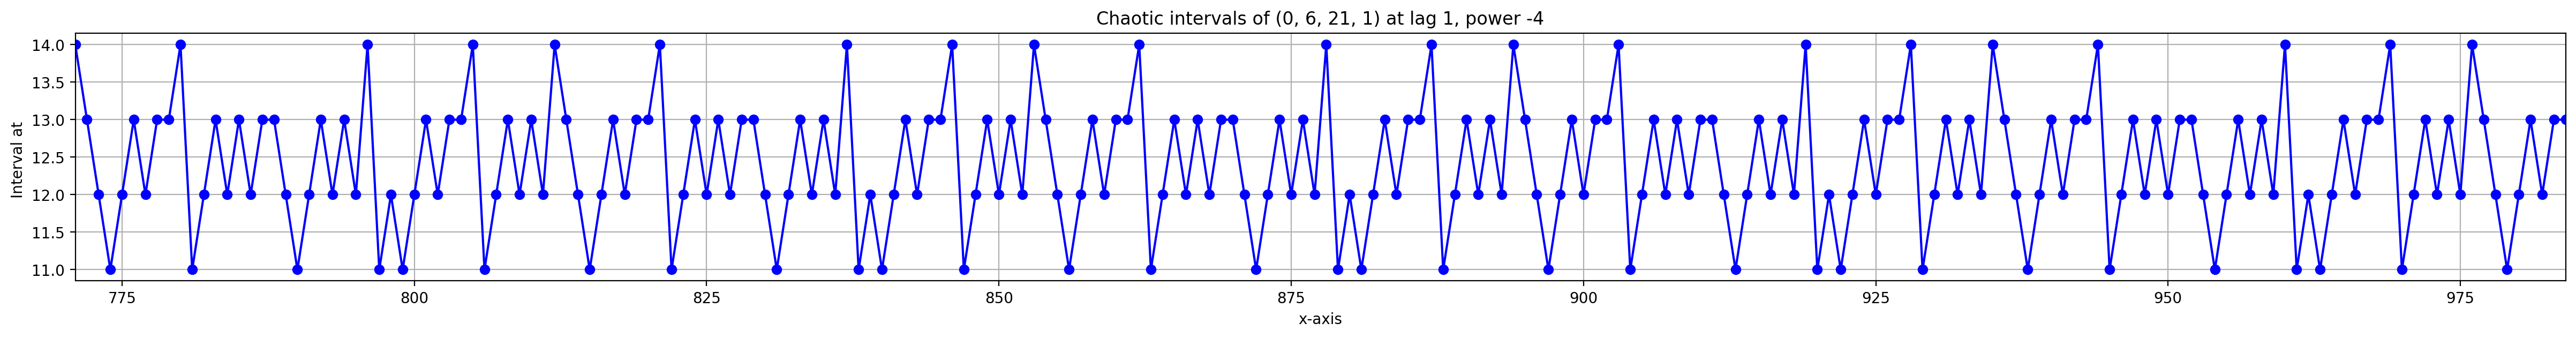

In [ ]:
inter_lag = 1
power = -4
cycle_idx = 0
size = 257

intervals = plot_chaotic_interval_closely(choatic_profiles, inter_lag, power, cycle_idx, size, chaotic_only)
# intervals

#### 250511 부동소수점 오류 디버깅 과정

In [1]:
from process import adjust_to_eighth_note, label_active_chord_by_onset, get_ready_with_lags

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes, tempo = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adn_1_chord = label_active_chord_by_onset(adn_1_real) # 33*59
adn_2_chord = label_active_chord_by_onset(adn_2_real) # 32*59

adn_i = get_ready_with_lags(adn_1_chord, adn_2_chord)

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


In [2]:
from process import (group_notes_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
# module_chord = adn_1_chord[:32]
active_module = group_notes_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
notes_dict['name'] = 'notes'

In [3]:
from util import (get_chords_intra_connected, get_chords_inter_connected, get_outta_reach, is_distance_matrix_from)
from professor import generateBarcode

refine_dict = notes_dict

weight_mtrx_1 = get_chords_intra_connected(adn_i[1][0], lag=1)
weight_mtrx_2 = get_chords_intra_connected(adn_i[2][0], lag=1)
intra_weights = weight_mtrx_1 + weight_mtrx_2

inter_lag = 1
power = -2
inter_weight = get_chords_inter_connected(adn_i[1][inter_lag], adn_i[2][inter_lag], lag=inter_lag)
outta_reach_test = get_outta_reach(inter_weight, power = power)

In [4]:
# focus_n = [5, 6, 9, 18, 8, 15]
focus_n = [1, 7, 22, 2]
cycle_set = set(focus_n)

focus_c = []
for key, value in notes_dict.items():
    if cycle_set & set(value) :
        focus_c.append(key)

focus_c

[0, 1, 2, 3, 4]

In [ ]:
rate_start = 0.0
rate_end = 1.5

step = 10**power
start = round(rate_start / step)
end = round(rate_end / step)

cycles_profile = []
# hypothesis = []

for a in range(start, end, 1) :

    rate = round(a * step, -power)
    
    timeflow_weight = intra_weights + rate * inter_weight 
    timeflow_distance = is_distance_matrix_from(timeflow_weight, refine_dict, out_of_reach = outta_reach_test, power = power)
    # temp = timeflow_distance.loc[focus_n, focus_n]

    birthDeath = generateBarcode(mat = timeflow_distance.values, exactStep = True, birthDeathSimplex=False, sortDimension=False)
    if birthDeath :
        print(f"on rate {rate}...")
        result = (rate, birthDeath)
        cycles_profile.append(result)

    # # 모든 조합에 대한 edge 거리 계산 및 저장
    # edges = []
    # for i in range(len(focus_n)):
    #     for j in range(i+1, len(focus_n)):  # 중복 계산 방지
    #         node1 = focus_n[i]
    #         node2 = focus_n[j]
    #         distance = temp.loc[node1, node2]  # DataFrame에서 거리 가져오기
    #         edges.append((distance, node1, node2))  # (거리, 노드1, 노드2) 튜플 저장

    # # 거리를 기준으로 정렬
    # sorted_edges = sorted(edges, key=lambda x: x[0])
    
    # hypothesis.append((rate, sorted_edges))

In [ ]:
from util import split_cycles_by_consecutive

cycle_persistence_now = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-4_0.0~1.5.pkl', dir="./pickle")
non_consecutive_cycles_now, consecutive_cycles_now = split_cycles_by_consecutive(cycle_persistence_now, out_of_reach = outta_reach_test, power = power)

# cycle_persistence_past = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-5_0.0~1.5.pkl', dir="./pickle/fp_error/lag 1")
# non_consecutive_cycles_past, consecutive_cycles_past = split_cycles_by_consecutive(cycle_persistence_past, out_of_reach = None, power = -5)
non_consecutive_cycles_past = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-5_0.0~1.5_n.pkl', dir="./pickle/fp_error/lag 1")
consecutive_cycles_past = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-5_0.0~1.5_c.pkl', dir="./pickle/fp_error/lag 1")

In [ ]:
cycles_now_c = set()
for cycle_now_c in consecutive_cycles_now.keys():
    cycles_now_c.add(cycle_now_c)

cycles_now_n = set()
for cycle_now_n in non_consecutive_cycles_now.keys():
    cycles_now_n.add(cycle_now_n)

cycles_past_c = set()
for cycle_past_c in consecutive_cycles_past.keys():
    cycles_past_c.add(cycle_past_c)

cycles_past_n = set()
for cycle_past_n in non_consecutive_cycles_past.keys():
    cycles_past_n.add(cycle_past_n)

print(len(cycle_persistence_past), len(cycle_persistence_now))

cycles_past = cycles_past_n.union(cycles_past_c)
cycles_now = cycles_now_n.union(cycles_now_c)

In [ ]:
print(len(cycles_past & cycles_now))
print(len(cycles_past - cycles_now), cycles_past - cycles_now) # 있었는데, 없어진
print(len(cycles_now - cycles_past)) 
print("\n")

print(len(cycles_past_c & cycles_now_c))
print(len(cycles_past_c - cycles_now_c), cycles_past_c - cycles_now_c) # 연속이었는데 연속이 아니게 된
print(len(cycles_now_c - cycles_past_c), cycles_now_c - cycles_past_c) # 연속이 아니었는데 연속이게 된
print("\n")

print(len(cycles_past_n & cycles_now_n)) 
print(len(cycles_past_n - cycles_now_n), cycles_past_n - cycles_now_n) 
print(len(cycles_now_n - cycles_past_n))

In [ ]:
from util import plot_cycle_BirthDeath_over_rate

temp_dict = dict()

cons_cycles_from_noise = cycles_past_c - cycles_now_c
for cycle in cons_cycles_from_noise :
    temp_dict[cycle] = consecutive_cycles_past[cycle]

ncons_cycles_from_noise = cycles_past_n - cycles_now_n
for cycle in ncons_cycles_from_noise :
    temp_dict[cycle] = non_consecutive_cycles_past[cycle]

plot_cycle_BirthDeath_over_rate(temp_dict, subplot_in_a_row = 3, power = -4)

In [ ]:
from util import is_distance_matrix_from

rate = 0.06
timeflow_weight = intra_weights + rate * inter_weight
focus_c = [0, 1, 2, 3, 4]
temp_w = timeflow_weight.loc[focus_c, focus_c]
timeflow_distance = is_distance_matrix_from(temp_w, refine_dict, out_of_reach = outta_reach_test, power = -2)
focus_n = [1, 7, 22, 2]
temp_d = timeflow_distance.loc[focus_n, focus_n]


In [ ]:
from util import get_UTMconnected

focus_w = [2, 3]
weight_UTM = get_UTMconnected(timeflow_weight)
temp_w = weight_UTM.loc[focus_w, focus_w]
temp_w

In [ ]:
for info in hypothesis[6][1]:
    print(1/info[0], info[1], info[2])

In [ ]:
cycle_persistence_test = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-4_0.0~1.5.pkl', dir="./pickle/power -4/lag 1")

real_rates = []
for info in cycles_profile:
    real_rates.append(info[0])

local_rates = []
for rBD in cycle_persistence_test[(0, 6, 21, 1)]:
    local_rates.append(rBD[0])

real_rates == local_rates